# Hillik: a consistent High-&ell; likelihood

[``Hillik``](#https://github.com/mtristram/hillik) is a CMB likelihood based on cross-power spectra which can accomodate spectra from different survey (Planck, SPT, ACT) within a common modelisation of the foreground residuals.\
The likelihood is a Gaussian approximation with a signal model including CMB, galactic emissions (dust), poisson noise (from unmasked point sources) and extra-galactic emissions (tSZ, CIB, kSZ, SZxCIB).\
Nuisance parameters (calibration, polar efficiency, T-E-B leakage, ...) are associated to each survey with the exact same treatment as in the original studies.

In [1]:
import MCtools
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Models

### Planck

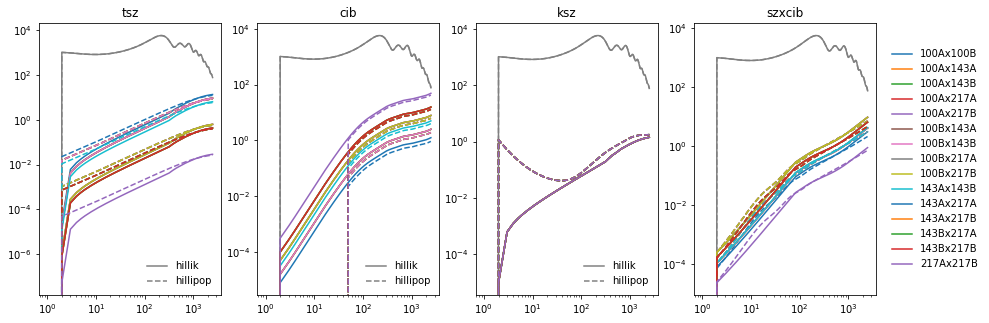

In [2]:
import itertools
xfreq = list(itertools.combinations( ['100A','100B','143A','143B','217A','217B'],2))

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_plk_fgs.npy")))
fg_list = ["dust","tsz","ksz","cib","szxcib","ps_radio","ps_dusty","ps"]
hlp = dict( zip(fg_list,np.load( f"{DBdir}/../hillipop_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','hillipop'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label="%sx%s" % xfreq[c])
        p2=plot( abs(hlp[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### SPT

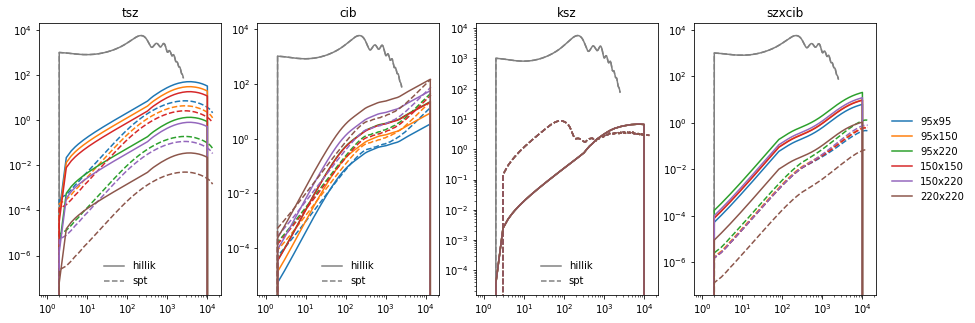

In [3]:
xfreq = ["95x95","95x150","95x220","150x150","150x220","220x220"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_spt_fgs.npy")))
fg_list = ["ps_dg","cib","ps_rg","tsz","ksz","dust","szxcib","szxradio"]
spt = dict( zip(fg_list,np.load( f"{DBdir}/../spt_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','spt'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(spt[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (deep)

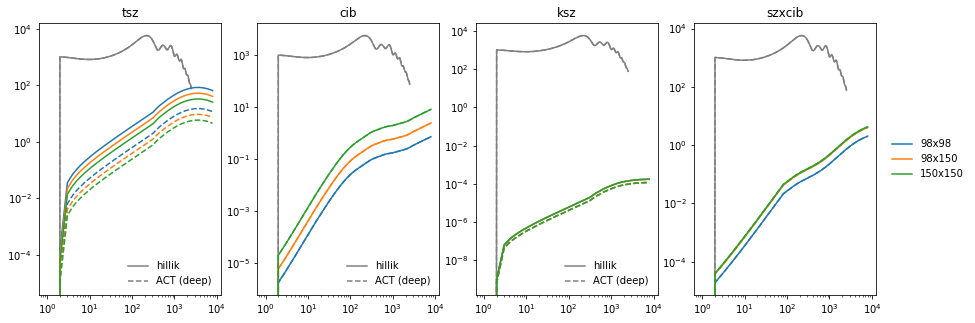

In [4]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTd_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_deep_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (deep)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (wide)

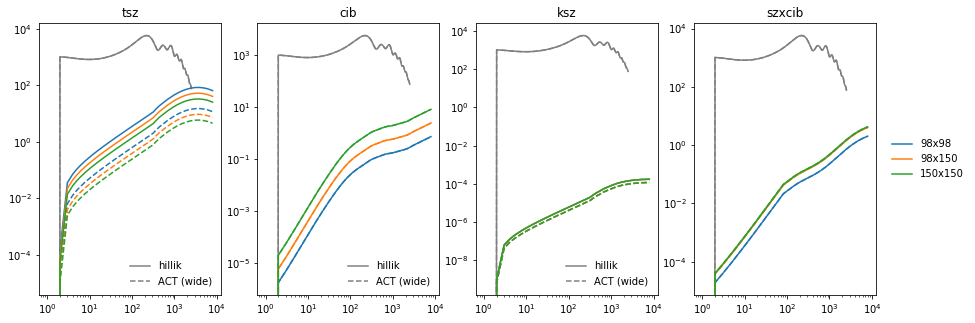

In [5]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTw_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_wide_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (wide)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

## Each survey

In [6]:
runnames = ['hillik_plk','hillik_spt','hillik_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, nelts=20000) for run in runnames]

hillik_plk: 256933  175140  191948  191088 
hillik_spt: 787716  623145  596281  717599 
hillik_act: 859001  669936  832221  901294 


                         hillik_plk                 hillik_spt                 hillik_act
ombh2           =  0.022224 +/- 0.000202  |   0.023334 +/- 0.001885  |   0.021512 +/- 0.000664
omch2           =  0.119137 +/- 0.001932  |   0.114630 +/- 0.015893  |   0.131488 +/- 0.007588
theta           =  1.040811 +/- 0.000449  |   1.039698 +/- 0.006339  |   1.040795 +/- 0.001401
tau             =  0.056410 +/- 0.006672  |   0.054594 +/- 0.006803  |   0.054911 +/- 0.006893
ns              =  0.963426 +/- 0.005541  |   0.978828 +/- 0.022067  |   0.988456 +/- 0.010593
logA            =  3.042686 +/- 0.014960  |   2.982096 +/- 0.077995  |   3.062628 +/- 0.052455


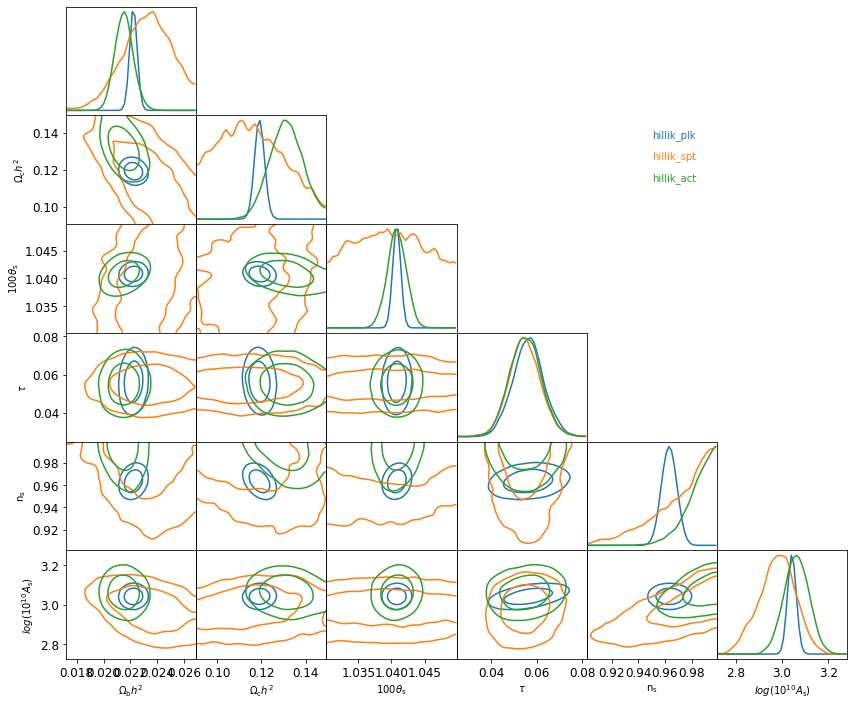

In [7]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)
print( "%35s %26s %26s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

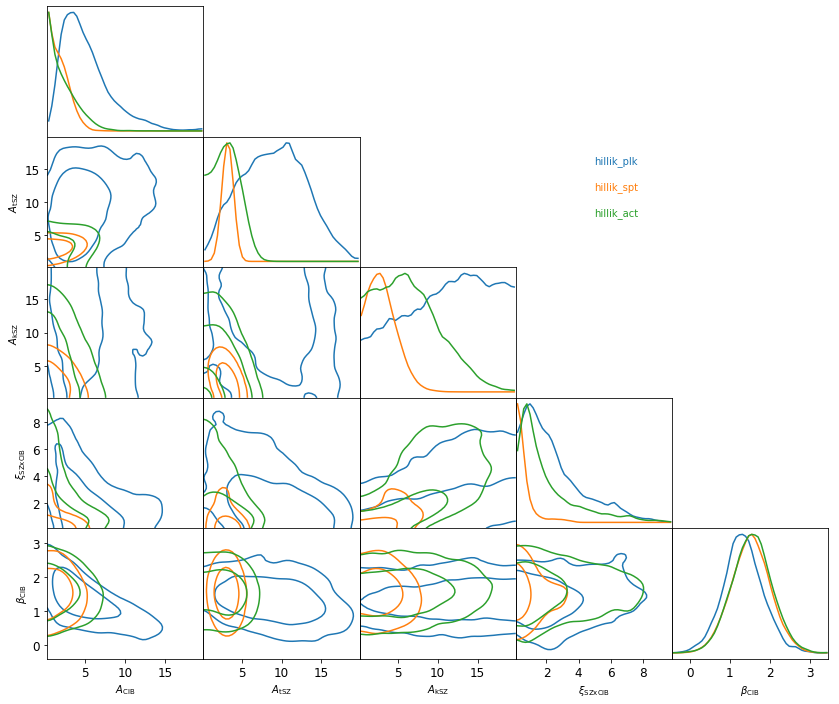

In [8]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Combination

In [21]:
runnames = ['hillik_plk','hillik_plkspt','hillik_plkact','hillik_plksptact']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]

hillik_plk: 257651  175806  192639  191806 
hillik_plkspt: 486325  477769  419769  469137 
hillik_plkact: 530296  696075  547434  626349 
hillik_plksptact: 708245  901657  700167  608225 


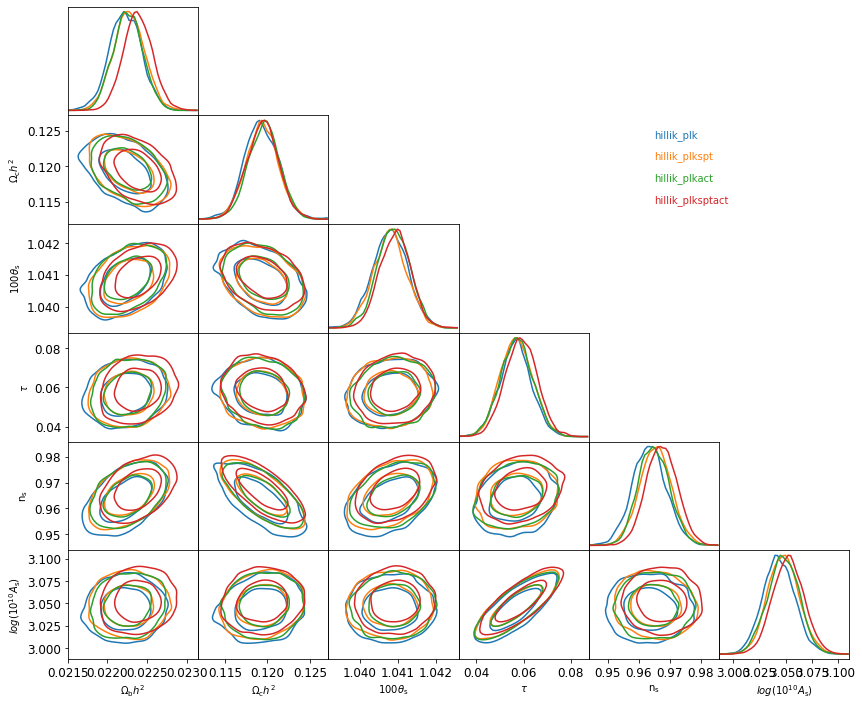

In [22]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

In [11]:
print( "%35s %28s %28s %28s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                         hillik_plk                hillik_plkspt                hillik_plkact             hillik_plksptact
ombh2           =  0.022219 +/- 0.000198  |   0.022266 +/- 0.000199  |   0.022256 +/- 0.000186  |   0.022380 +/- 0.000185
omch2           =  0.119173 +/- 0.001968  |   0.119360 +/- 0.001908  |   0.119650 +/- 0.001844  |   0.119446 +/- 0.001885
theta           =  1.040810 +/- 0.000462  |   1.040808 +/- 0.000450  |   1.040893 +/- 0.000432  |   1.040954 +/- 0.000413
tau             =  0.056527 +/- 0.006701  |   0.056936 +/- 0.007205  |   0.057178 +/- 0.006966  |   0.058659 +/- 0.006795
ns              =  0.963367 +/- 0.005459  |   0.965282 +/- 0.005115  |   0.964700 +/- 0.004906  |   0.967299 +/- 0.005020
logA            =  3.042776 +/- 0.014864  |   3.047835 +/- 0.014791  |   3.047922 +/- 0.014919  |   3.052120 +/- 0.014462


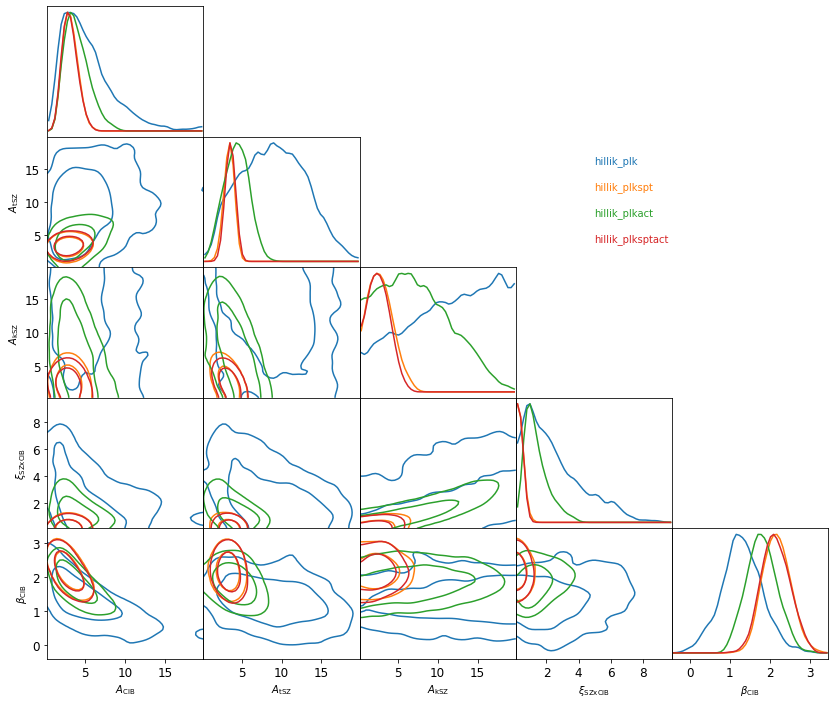

In [12]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Alens

In [23]:
runnames = ['hillik_plk_Alens','hillik_plkact_Alens','hillik_plkspt_Alens','hillik_plksptact_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]

hillik_plk_Alens: 93918  194222  140408  131627 
hillik_plkact_Alens: 769079  627704  610706  572047 
hillik_plkspt_Alens: 460822  376959  519387  506385 
hillik_plksptact_Alens: 615639  483539  506822  587985 


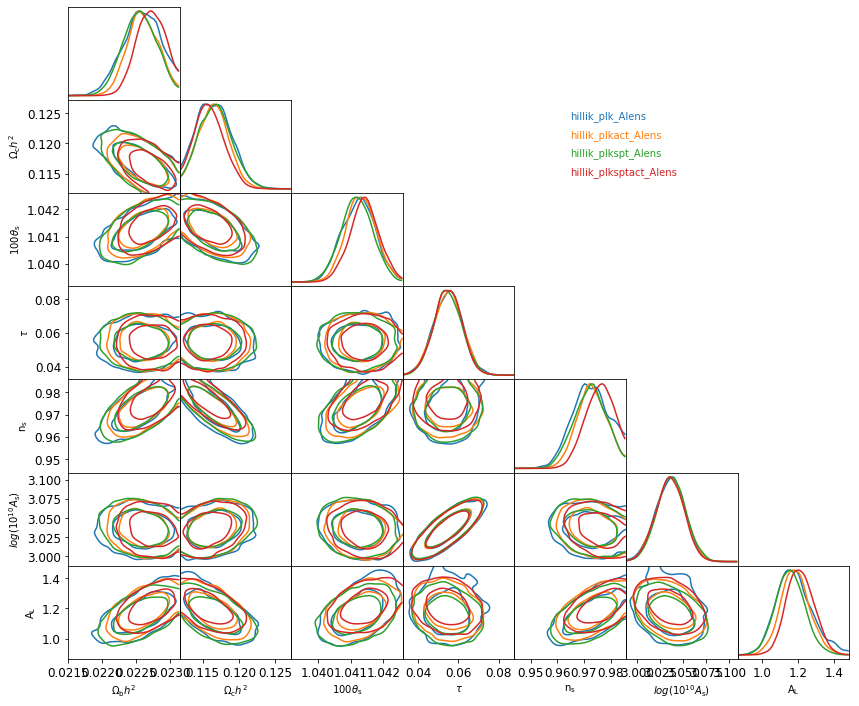

In [24]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.triangle( chains, listpar, labels=runnames, smooth=1.5)

In [15]:
print( "%35s %28s %28s %28s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                   hillik_plk_Alens          hillik_plkact_Alens          hillik_plkspt_Alens       hillik_plksptact_Alens
ombh2           =  0.022626 +/- 0.000312  |   0.022609 +/- 0.000236  |   0.022570 +/- 0.000260  |   0.022748 +/- 0.000231
omch2           =  0.116296 +/- 0.002563  |   0.116326 +/- 0.002211  |   0.116645 +/- 0.002390  |   0.115650 +/- 0.002132
theta           =  1.041274 +/- 0.000524  |   1.041309 +/- 0.000465  |   1.041197 +/- 0.000481  |   1.041440 +/- 0.000455
tau             =  0.054870 +/- 0.007106  |   0.054663 +/- 0.007151  |   0.054564 +/- 0.006958  |   0.054497 +/- 0.006763
ns              =  0.973425 +/- 0.007857  |   0.973388 +/- 0.005994  |   0.972685 +/- 0.006449  |   0.976698 +/- 0.005903
logA            =  3.035983 +/- 0.015563  |   3.035911 +/- 0.015614  |   3.037275 +/- 0.015938  |   3.035055 +/- 0.015401
Alens           =  1.171135 +/- 0.097376  |   1.183074 +/- 0.078397  |   1.153322 +/- 0.079618  |   1.212347 +/- 0.076074


In [16]:
for i in range(len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.171 +/- 0.097 (1.76σ) hillik_plk_Alens
1.183 +/- 0.078 (2.34σ) hillik_plkact_Alens
1.153 +/- 0.080 (1.93σ) hillik_plkspt_Alens
1.212 +/- 0.076 (2.79σ) hillik_plksptact_Alens


## Impact of Hillik

In [17]:
runnames = ['plk_spt_act','hillik_plksptact','plk_spt_act_Alens','hillik_plksptact_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]

plk_spt_act: 348141  304567  257398  257965 
hillik_plksptact: 705199  896524  698074  605595 
plk_spt_act_Alens: 235732  185319  255695  257912 
hillik_plksptact_Alens: 613003  481525  504827  585360 


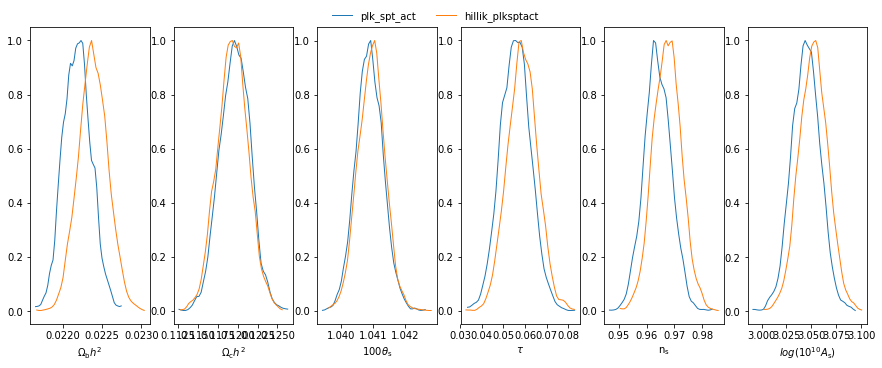

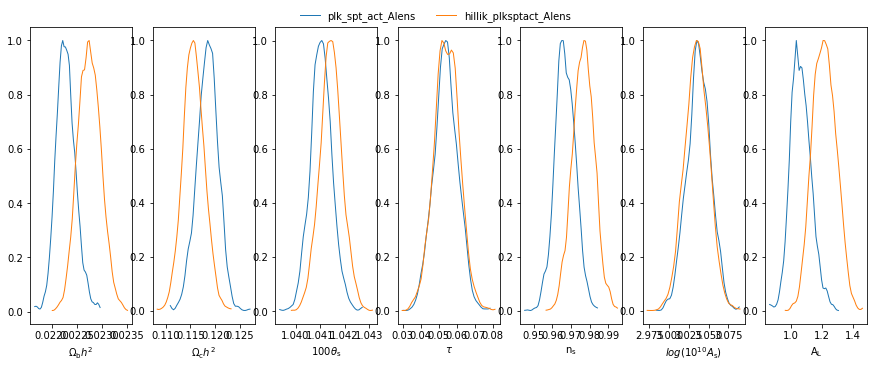

In [18]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.posterior1d( chains[:2], listpar[:-1], labels=runnames[:2], ncol=1, figsize=(15,5))
fig=MCtools.posterior1d( chains[2:], listpar, labels=runnames[2:], ncol=1, figsize=(15,5))

In [19]:
for i in range(2,len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.061 +/- 0.063 (0.98σ) plk_spt_act_Alens
1.213 +/- 0.076 (2.81σ) hillik_plksptact_Alens


In [2]:
#SZ sector
runnames = ['spt_fixedLCDM','hillik_spt','hillik_plksptact']
spt = [MCtools.mergeMC( f"{DBdir}/{run}/mcmc", burnin=0.9, nelts=5000) for run in runnames]

spt_fixedLCDM: 34761  45761  31241  46201 
hillik_spt: 817064  637724  612267  734707 
hillik_plksptact: 725419  921791  714106  622531 


Text(0, 0.5, 'D$^{kSZ}_{3000}\\quad(\\mu K^2)$')

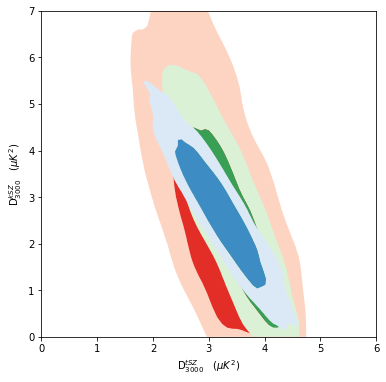

In [7]:
#Figure 3 [Reichard et al. 2020]
figure(figsize=(6,6))
MCtools.posterior2d(spt[1],'Atsz','Aksz', cmap='Reds', levels=[0.68,0.95], alpha=1)
MCtools.posterior2d(spt[2],'Atsz','Aksz', cmap='Greens', levels=[0.68,0.95], alpha=1)
MCtools.posterior2d(spt[0],'czero_tsz','czero_ksz', cmap='Blues', levels=[0.68,0.95], alpha=1)
xlim(0,6)
ylim(0,7)
xlabel('D$^{tSZ}_{3000}\quad(\mu K^2)$')
ylabel('D$^{kSZ}_{3000}\quad(\mu K^2)$')

Text(0, 6.2, 'tSZ')

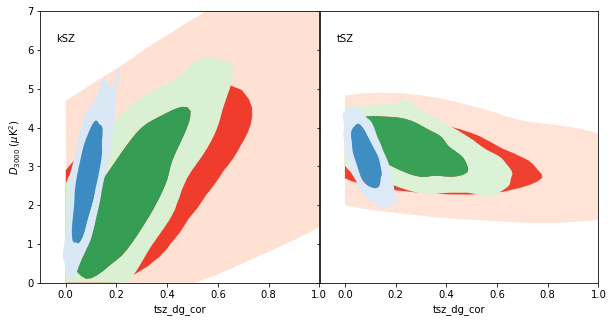

In [10]:
#Figure 4 Reichardt et al.
figure(figsize=(10,5))
subplot( 1, 2, 1)
MCtools.posterior2d( spt[1], "xi", "Aksz", cmap="Reds", levels=[0.68,0.95], alpha=1)
MCtools.posterior2d( spt[2], "xi", "Aksz", cmap="Greens", levels=[0.68,0.95], alpha=1)
MCtools.posterior2d( spt[0], "tsz_dg_cor", "czero_ksz", cmap="Blues", levels=[0.68,0.95], alpha=1)
xlim(-0.1,1.)
ylim(0.,7)
ylabel( '$D_{3000}$ ($\\mu$K$^2$)')
text( 0, 6.2, 'kSZ', ha='center')
subplot( 1, 2, 2)
MCtools.posterior2d( spt[1], "xi", "Atsz", cmap="Reds", levels=[0.68,0.95], alpha=1)
MCtools.posterior2d( spt[2], "xi", "Atsz", cmap="Greens", levels=[0.68,0.95], alpha=1)
MCtools.posterior2d( spt[0], "tsz_dg_cor", "czero_tsz", cmap="Blues", levels=[0.68,0.95], alpha=1)
subplots_adjust(wspace=0.001)
ylabel("")
gca().set_yticklabels([])
xlim(-0.1,1.)
ylim(0.,7)
text( 0, 6.2, 'tSZ', ha='center')